# EDA 01 · Analiza Zbioru Respiratory Sound Database ICBHI 2017

<div style="background-color: #f8f9fa; border-left: 4px solid #2b6cb0; padding: 12px 16px; margin-bottom: 20px; border-radius: 0 4px 4px 0;">
  <strong>Praca Inżynierska:</strong> -- <br>
  <strong>Autorzy:</strong> Norbert Gwiazda, Mateusz Ciurzyński | <strong>Data:</strong> 2026-09-02<br>
  <strong>Zbiór danych:</strong> Respiratory Sound Database (ICBHI 2017)<br>
  <strong>Cel:</strong> --
</div>

---

## Spis treści
- [1. Kontekst i Charakterystyka Bazy Danych](#1-kontekst-i-charakterystyka-bazy-danych)
- [2. Środowisko i Import Bibliotek](#2-środowisko-i-import-bibliotek)
- [3. Wczytanie danych](#3-wczytanie-danych)
- [4. Analiza kategoryczna](#4-analiza-kategoryczna)
  - [4.1 Typy cyklów oddechowych](#41-typy-cyklów-oddechowych)

---

## 1. Kontekst i Charakterystyka Bazy Danych

Zbiór *Respiratory Sound Database* zawiera próbki cykli oddechowych, zebranych niezależnie przez dwa zespoły naukowe z Portugalii i Grecji na przestrzeni kilku: 
- **Zespół portugalski:** *School of Health Sciences* na Uniwersytecie w Aveiro (ESSUA) - nagrania w Laboratorium Badań i Rehabilitacji Oddechowej (**Lab3R**) oraz w Szpitalu Infante D. Pedro w Aveiro.
- **Zespół grecki:** *Arystotelesowski Uniwersytet w Tesalonikach* (AUTH) oraz *Uniwersytet w Coimbrze* (UC) — nagrania w Szpitalu Głównym Papanikolaou w Tesalonikach oraz w Szpitalu Ogólnym w Imathia.

Baza danych zawiera ponad $5,5$ godzin nagrań, zawierających około $6898$ cykli oddechowych. Dane zebrano od $126$ pacjentów. Nazwy plików z nagraniami zawierają metadane określające indeks pacjenta, miejsce badania, sprzęt użyty do badania oraz sposób badania. Dodatkowo zbiór zawiera pliki tekstowe odpowiadające nagraniom określające czy i w którym momencie nagrania występują świsty lub trzaski.

Lokalizacje osłuchu:
- Trachea (Tc) - Tchawica
- Anterior left (Al) - Przód lewy (przednia lewa strona klatki piersiowej)
- Anterior right (Ar) - Przód prawy (przednia prawa strona klatki piersiowej)
- Posterior left (Pl) - Tył lewy (tylna lewa strona klatki piersiowej)
- Posterior right (Pr) - Tył prawy (tylna prawa strona klatki piersiowej)
- Lateral left (Ll) - Bok lewy (boczna lewa strona klatki piersiowej)
- Lateral right (Lr) - Bok prawy (boczna prawa strona klatki piersiowej)

Sprzęt użyty do badania:
- AKG C417L Microphone (AKGC417L), 
- 3M Littmann Classic II SE Stethoscope (LittC2SE), 
- 3M Litmmann 3200 Electronic Stethoscope (Litt3200), 
- WelchAllyn Meditron Master Elite Electronic Stethoscope (Meditron)

Dostępny jest również plik `ICBHI_Challenge_diagnosis.txt` zawierający diagnozę choroby dla każdego pacjenta. Możliwe diagnozy to:
- Zdrowy
- Astma
- Przewlekła Obturacyjna Choroba Płuc (COPD)
- Zakażenie górnych dróg oddechowych (URTI)
- Infekcja dolnych dróg oddechowych (LRTI)
- Rozstrzenie oskrzeli (Bronchiectasis)
- Pneumonia
- Zapalenie oskrzelików (Bronchiolitis)


## 2. Środowisko i Import Bibliotek

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.close_figures = True


import os
import warnings
from pathlib import Path

# Wizualizacja danych
import matplotlib.pyplot as plt

# Przetwarzanie i analiza numeryczna
import numpy as np
import pandas as pd
import seaborn as sns
from pyfonts import load_google_font
from pypalettes import load_cmap, load_palette

# Wyciszenie zbędnych ostrzeżeń
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Wczytanie czionek i palet kolorów
dark_two = load_palette("Dark2")
regular = load_google_font("Roboto", weight=400)
medium = load_google_font("Roboto", weight=500)
bold = load_google_font("Roboto", weight=700)
heavy = load_google_font("Roboto", weight=800)

# Ustawienie motywu
sns.set_theme(style="whitegrid")


## 3. Wczytanie danych

W pierwszej kolejności przyjrzymy się zawartości folderu zbioru danych

In [2]:
DATA_PATH = Path('../data/ICBHI_final_database/')
DIAGNOSIS_FILE = DATA_PATH / 'ICBHI_Challenge_diagnosis.txt'

audio_files = list(DATA_PATH.rglob("*.wav"))

print(f"Wszystkich nagrań: {len(audio_files)}")
print("Pierwsze 5 nagrań:")
for f in audio_files[:5]:
    print(f"  - {f.relative_to(DATA_PATH)}")

print("\n\nZawartość pliku metadanych:")
print(*DIAGNOSIS_FILE.read_text().splitlines()[:5], sep="\n")


Wszystkich nagrań: 920
Pierwsze 5 nagrań:
  - 163_2b2_Ll_mc_AKGC417L.wav
  - 139_1b1_Pr_sc_Litt3200.wav
  - 157_1b1_Al_sc_Meditron.wav
  - 138_2p2_Lr_mc_AKGC417L.wav
  - 177_2b4_Tc_mc_AKGC417L.wav


Zawartość pliku metadanych:
101	URTI
102	Healthy
103	Asthma
104	COPD
105	URTI


Przetworzenie plików audio może być problematyczne, dlatego załadujemy metadane do ramki pandas, a do samych plików audio umieścimy wskaźnik.

In [3]:
annotations = []
file_metadata = []

for file in DATA_PATH.iterdir():
    parts = file.stem.split("_")
    if len(parts) != 5:
        continue

    if file.suffix == ".wav":
        file_metadata.append({"patient_id": int(parts[0]),
                              "recording_id": parts[1],
                              "chest_location": parts[2],
                              "acquisition_mode": parts[3],
                              "recording_equipment": parts[4],
                              "filename": file.stem})
    elif file.suffix == ".txt":
        try:
            anno_df = pd.read_csv(
                file, sep="\t", names=["start", "end", "crackles", "wheezes"]
            )
            anno_df["filename"] = file.stem
            if anno_df is not None:
                annotations.append(anno_df)
        except Exception as e:
            print(f"Pominięto uszkodzony plik adnotacji {file.name}: {e}")

df = pd.concat(annotations, ignore_index=True)
metadata_df = pd.DataFrame(file_metadata)
patients_df = pd.read_csv(
    DIAGNOSIS_FILE, sep="\t", names=["patient_id", "diagnosis"]
)
merged_metadata = pd.merge(
    metadata_df, patients_df, on="patient_id", how="left"
)
df = pd.merge(df, merged_metadata, on="filename", how="left")

df.head()

,start,end,crackles,wheezes,filename,patient_id,recording_id,chest_location,acquisition_mode,recording_equipment,diagnosis
0,1.144,3.848,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
1,3.848,6.786,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
2,6.786,9.240,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
3,9.240,11.962,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
4,11.962,14.716,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   start                6898 non-null   float64
 1   end                  6898 non-null   float64
 2   crackles             6898 non-null   int64  
 3   wheezes              6898 non-null   int64  
 4   filename             6898 non-null   str    
 5   patient_id           6898 non-null   int64  
 6   recording_id         6898 non-null   str    
 7   chest_location       6898 non-null   str    
 8   acquisition_mode     6898 non-null   str    
 9   recording_equipment  6898 non-null   str    
 10  diagnosis            6898 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 592.9 KB


## 4. Analiza cech kategorycznych

Przygotowany zbiór danych poddamy teraz analizie, zaczynając od analizy kategorii. W ramach niej, przeanalizowana zostanie każda ze zmiennych kategorycznych. Po każdej podsekcji nastąpi zbiorcze podsumowanie wyników badań.

---

### 4.1 Miejsca odsłuchów


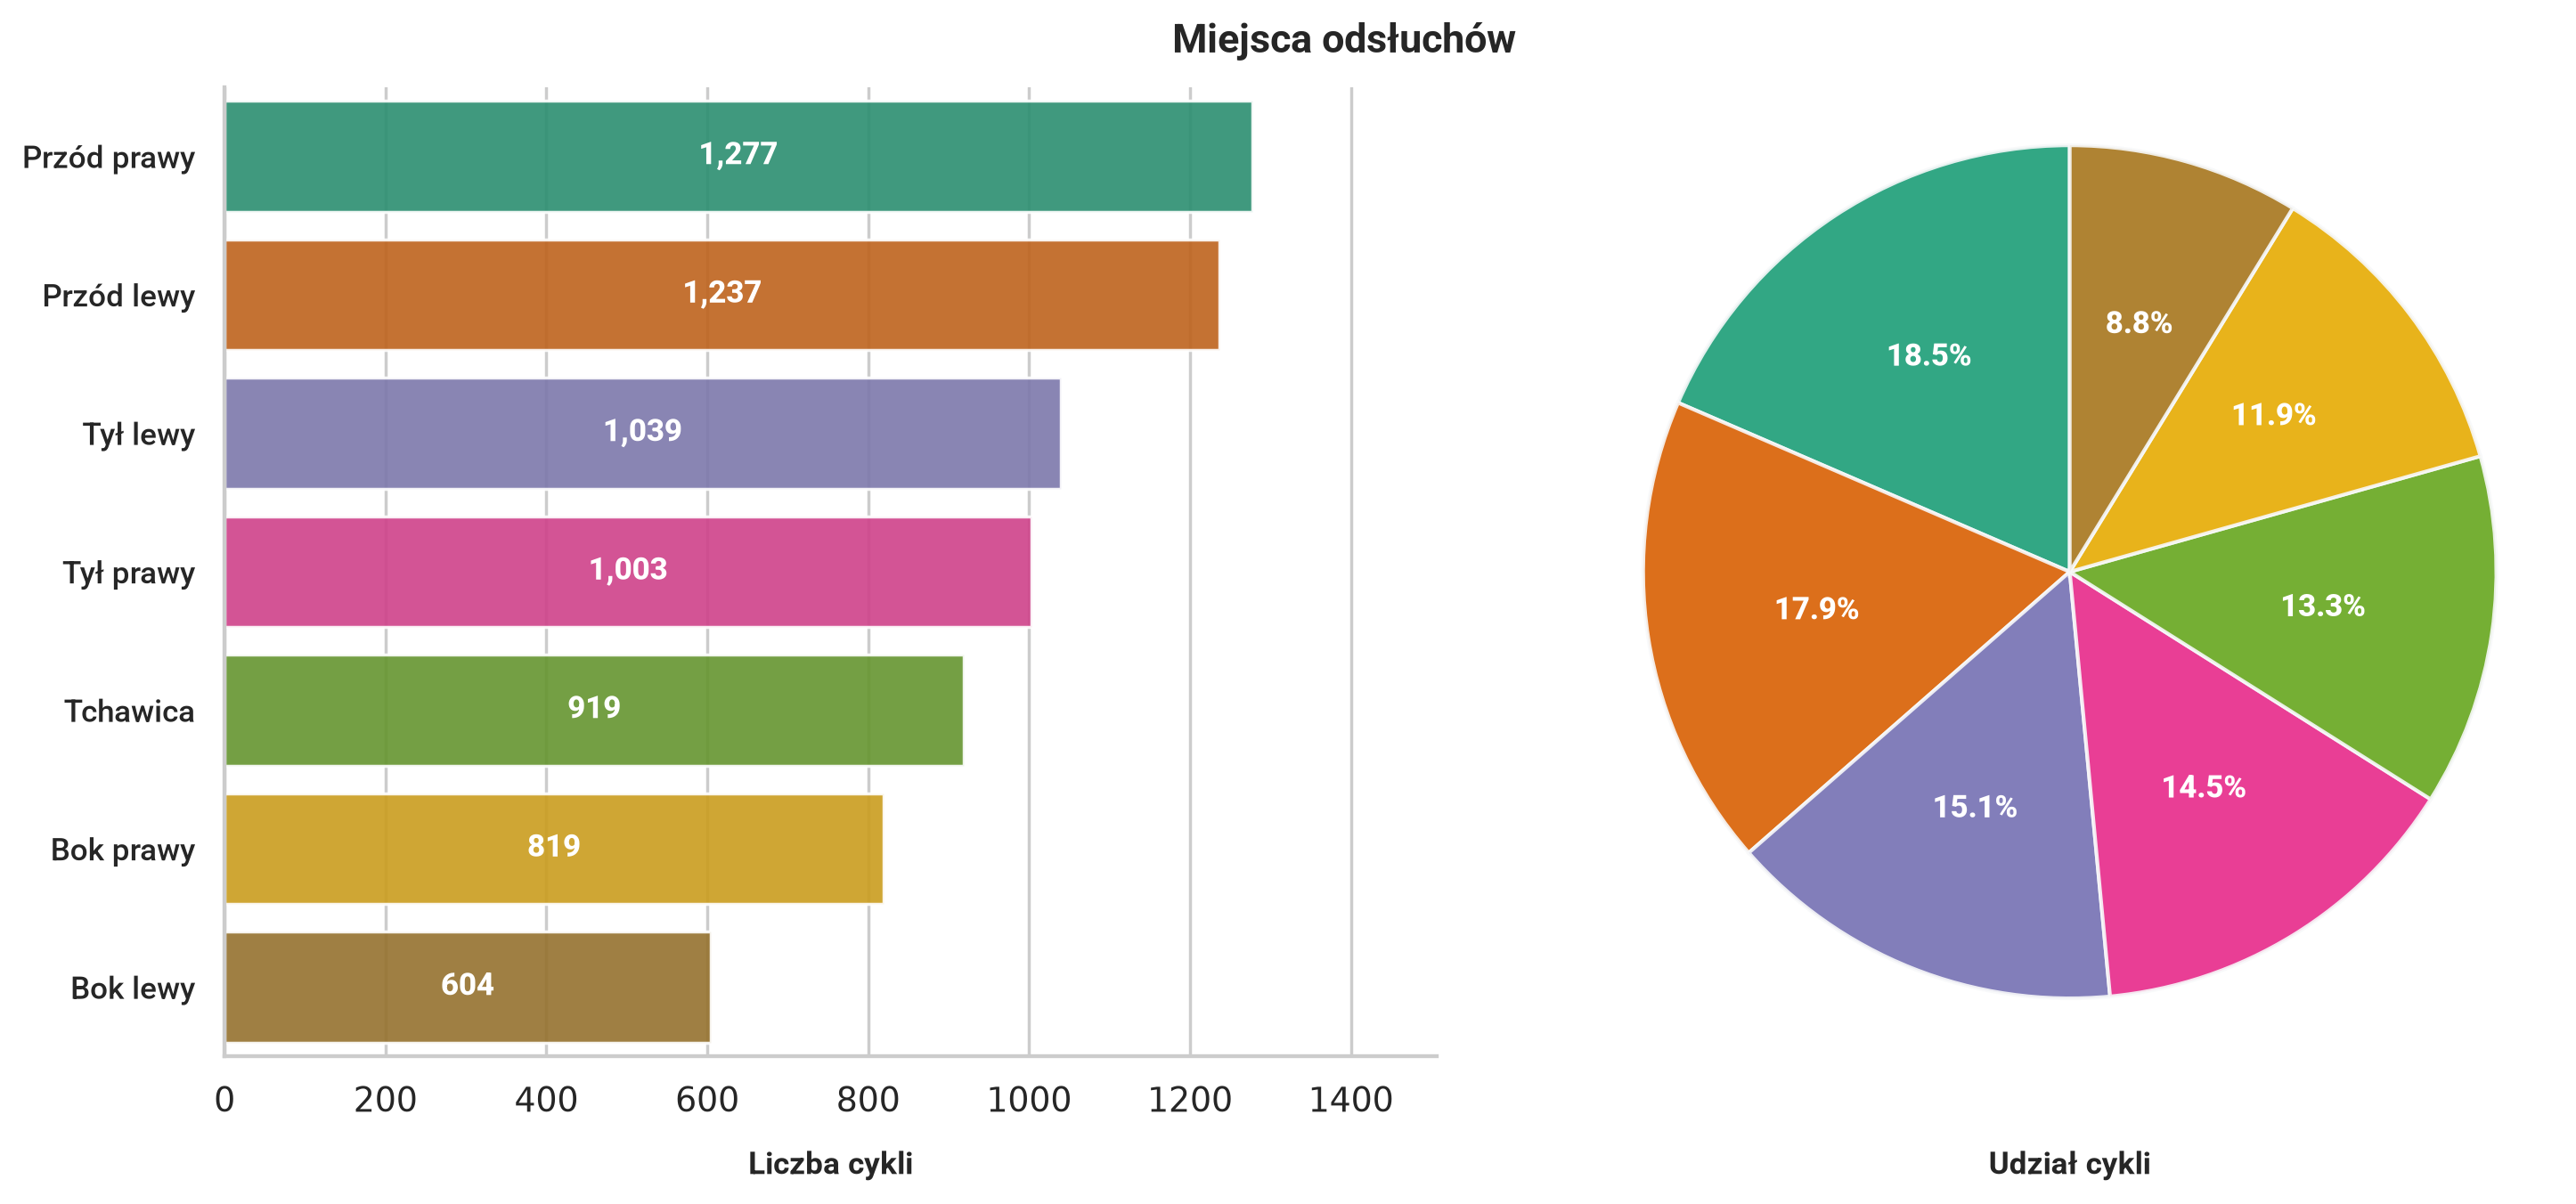

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['chest_location'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:7], strict=True))
labels_map = {
    "Ar": "Przód prawy",
    "Al": "Przód lewy",
    "Tc": "Tchawica",
    "Pl": "Tył lewy",
    "Pr": "Tył prawy",
    "Ll": "Bok lewy",
    "Lr": "Bok prawy"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['chest_location'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Miejsca odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [6]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Miejsca odsłuchów': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Miejsca odsłuchów,Liczebność,Udział (%)
0,Przód prawy,"1,277",18.51%
1,Przód lewy,"1,237",17.93%
2,Tył lewy,"1,039",15.06%
3,Tył prawy,"1,003",14.54%
4,Tchawica,919,13.32%
5,Bok prawy,819,11.87%
6,Bok lewy,604,8.76%


Rozkład miejsc odsłuchow cechuje się niewielkim niezbalansowaniem kategorii, które w przypadku najliczniejszej i najmniej licznej klasy charakteryzuje się ponad dwukrotną liczbą wystąpień jednej klasy względem drugiej. Tak łagodne niezbalansowanie nie wymaga stosowania technik przepróbkowania czy modyfikowania funkcji celu.

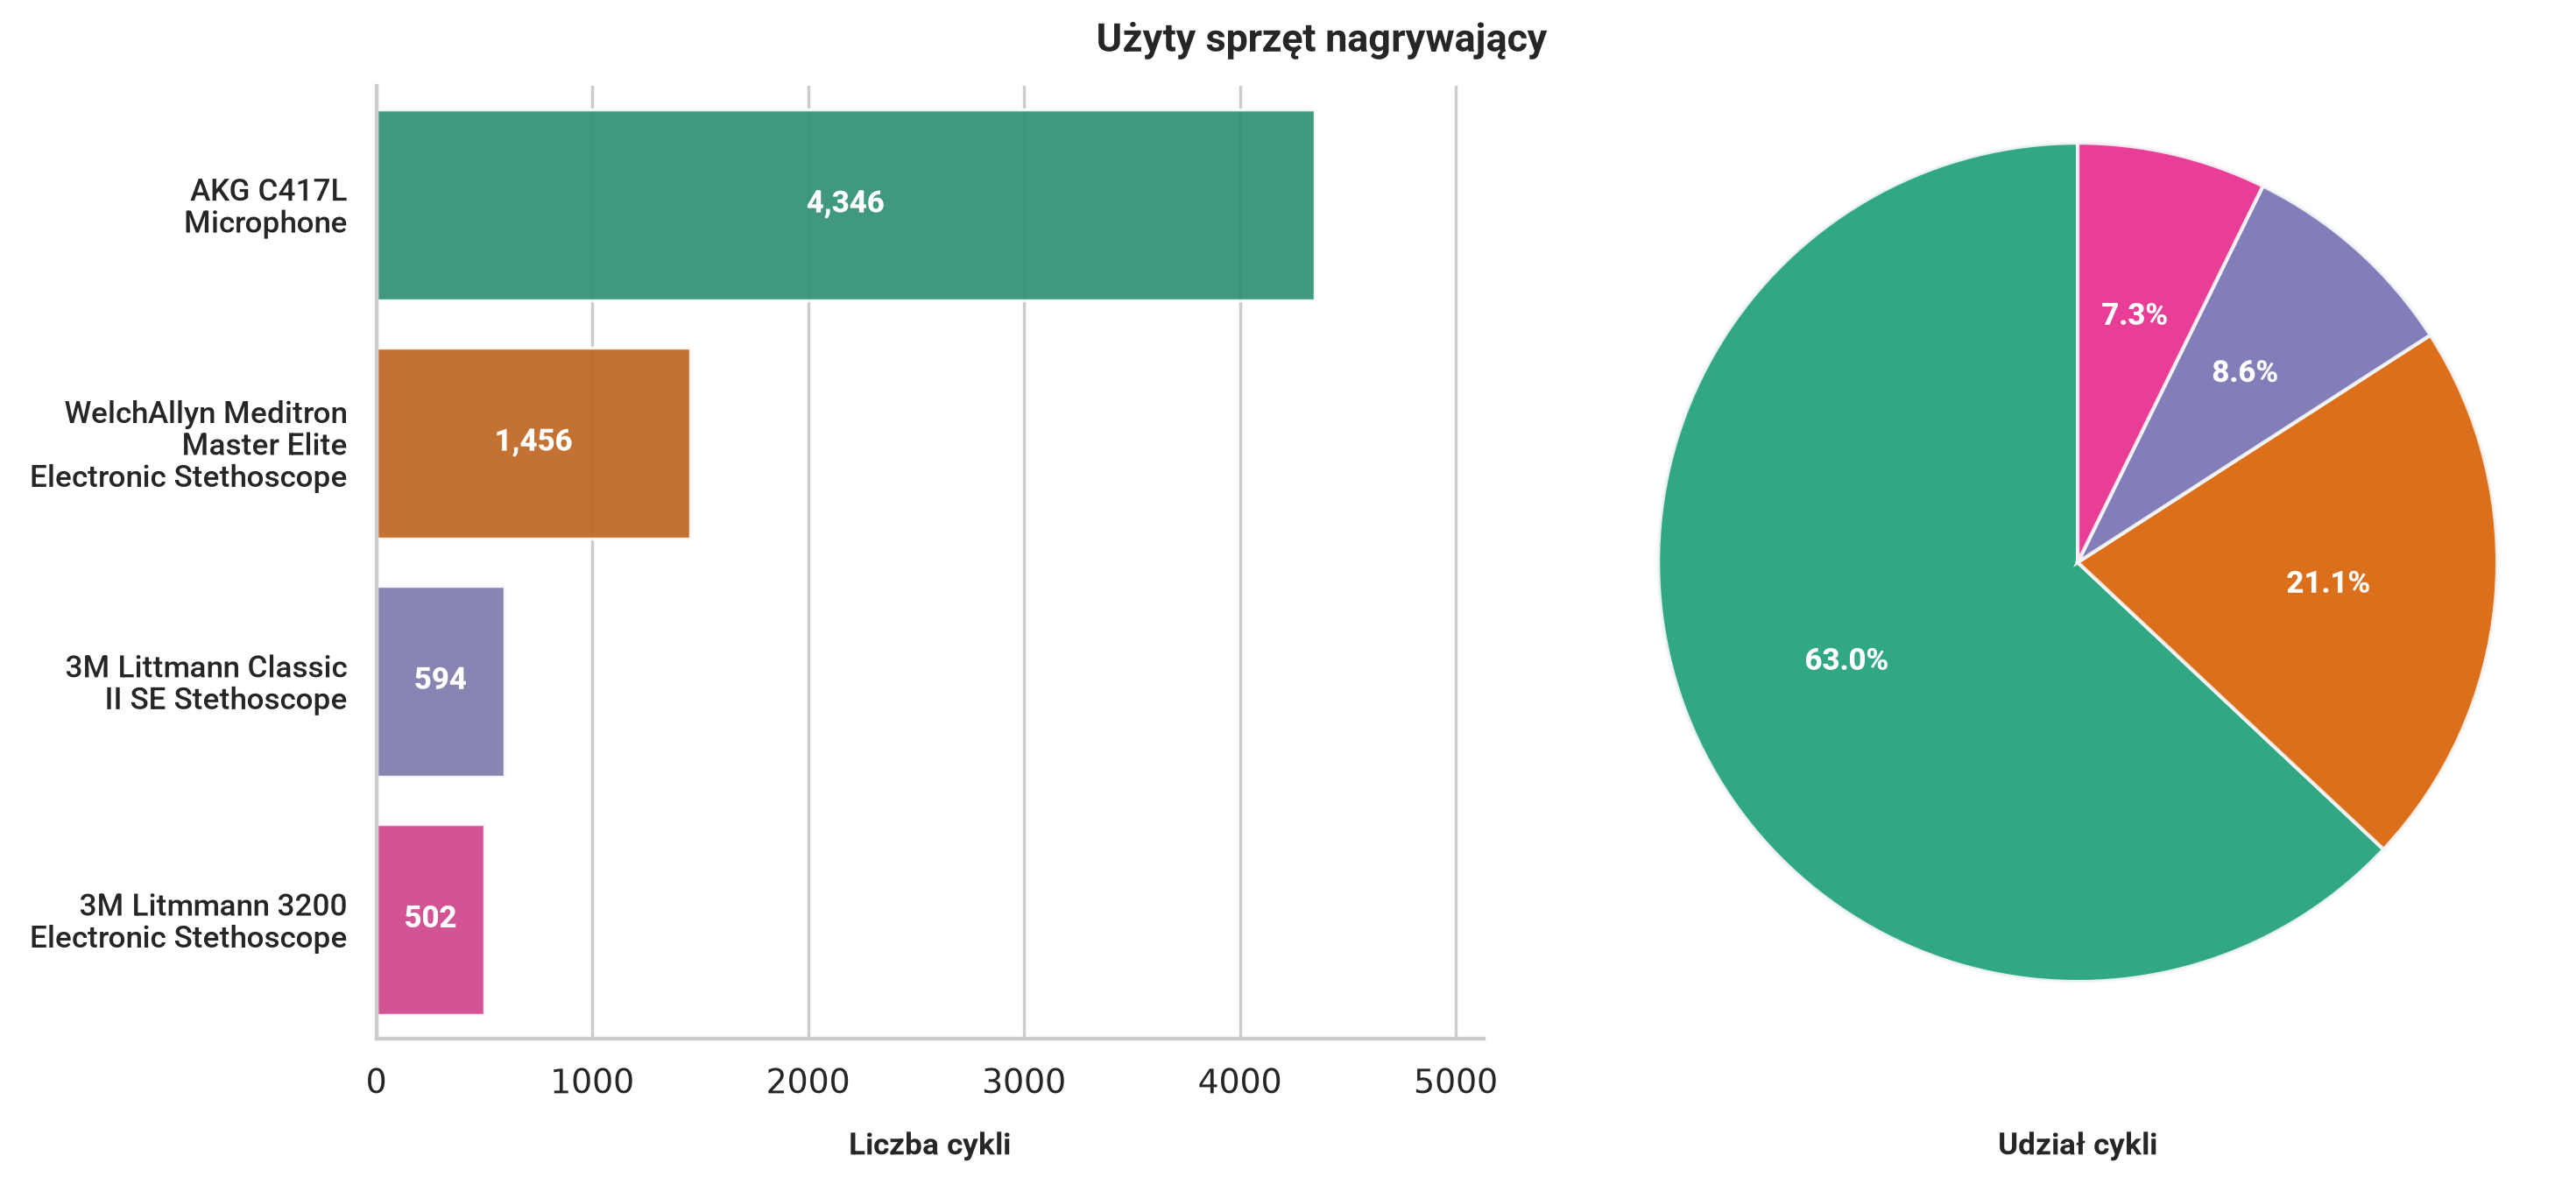

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['recording_equipment'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:4], strict=True))
labels_map = {
    "AKGC417L": "AKG C417L\n Microphone",
    "LittC2SE": "3M Littmann Classic\n II SE Stethoscope",
    "Litt3200": "3M Litmmann 3200\n Electronic Stethoscope",
    "Meditron": "WelchAllyn Meditron\n Master Elite\n Electronic Stethoscope"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Podmienione etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['recording_equipment'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Użyty sprzęt nagrywający ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [8]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Użyty sprzęt nagrywający': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Użyty sprzęt nagrywający,Liczebność,Udział (%)
0,AKG C417L\n Microphone,"4,346",63.00%
1,WelchAllyn Meditron\n Master Elite\n Electroni...,"1,456",21.11%
2,3M Littmann Classic\n II SE Stethoscope,594,8.61%
3,3M Litmmann 3200\n Electronic Stethoscope,502,7.28%


Najczęściej występującym stetoskopem w badaniach jest `AKG C417L Microphone` z ponad 3 krotną przewagą w liczbie wystąpień nad drugim `WelchAllyn Meditron Master Elite Electronic Stethoscope`. Niezbalansowanie jest zatem znaczące, a między najmniejszą i największą wynosi $9$-krotność na korzyść tej drugiej. Na dalszym etapie badania niezbędne jest zbadanie, czy wybrany stetoskop ma znaczący wpływ na jakość nagrań. Jeśli miałby, to jest szansa, że niezbalansowanie tej cechy mogłoby pogorszyć skuteczność ewentualnego modelu.

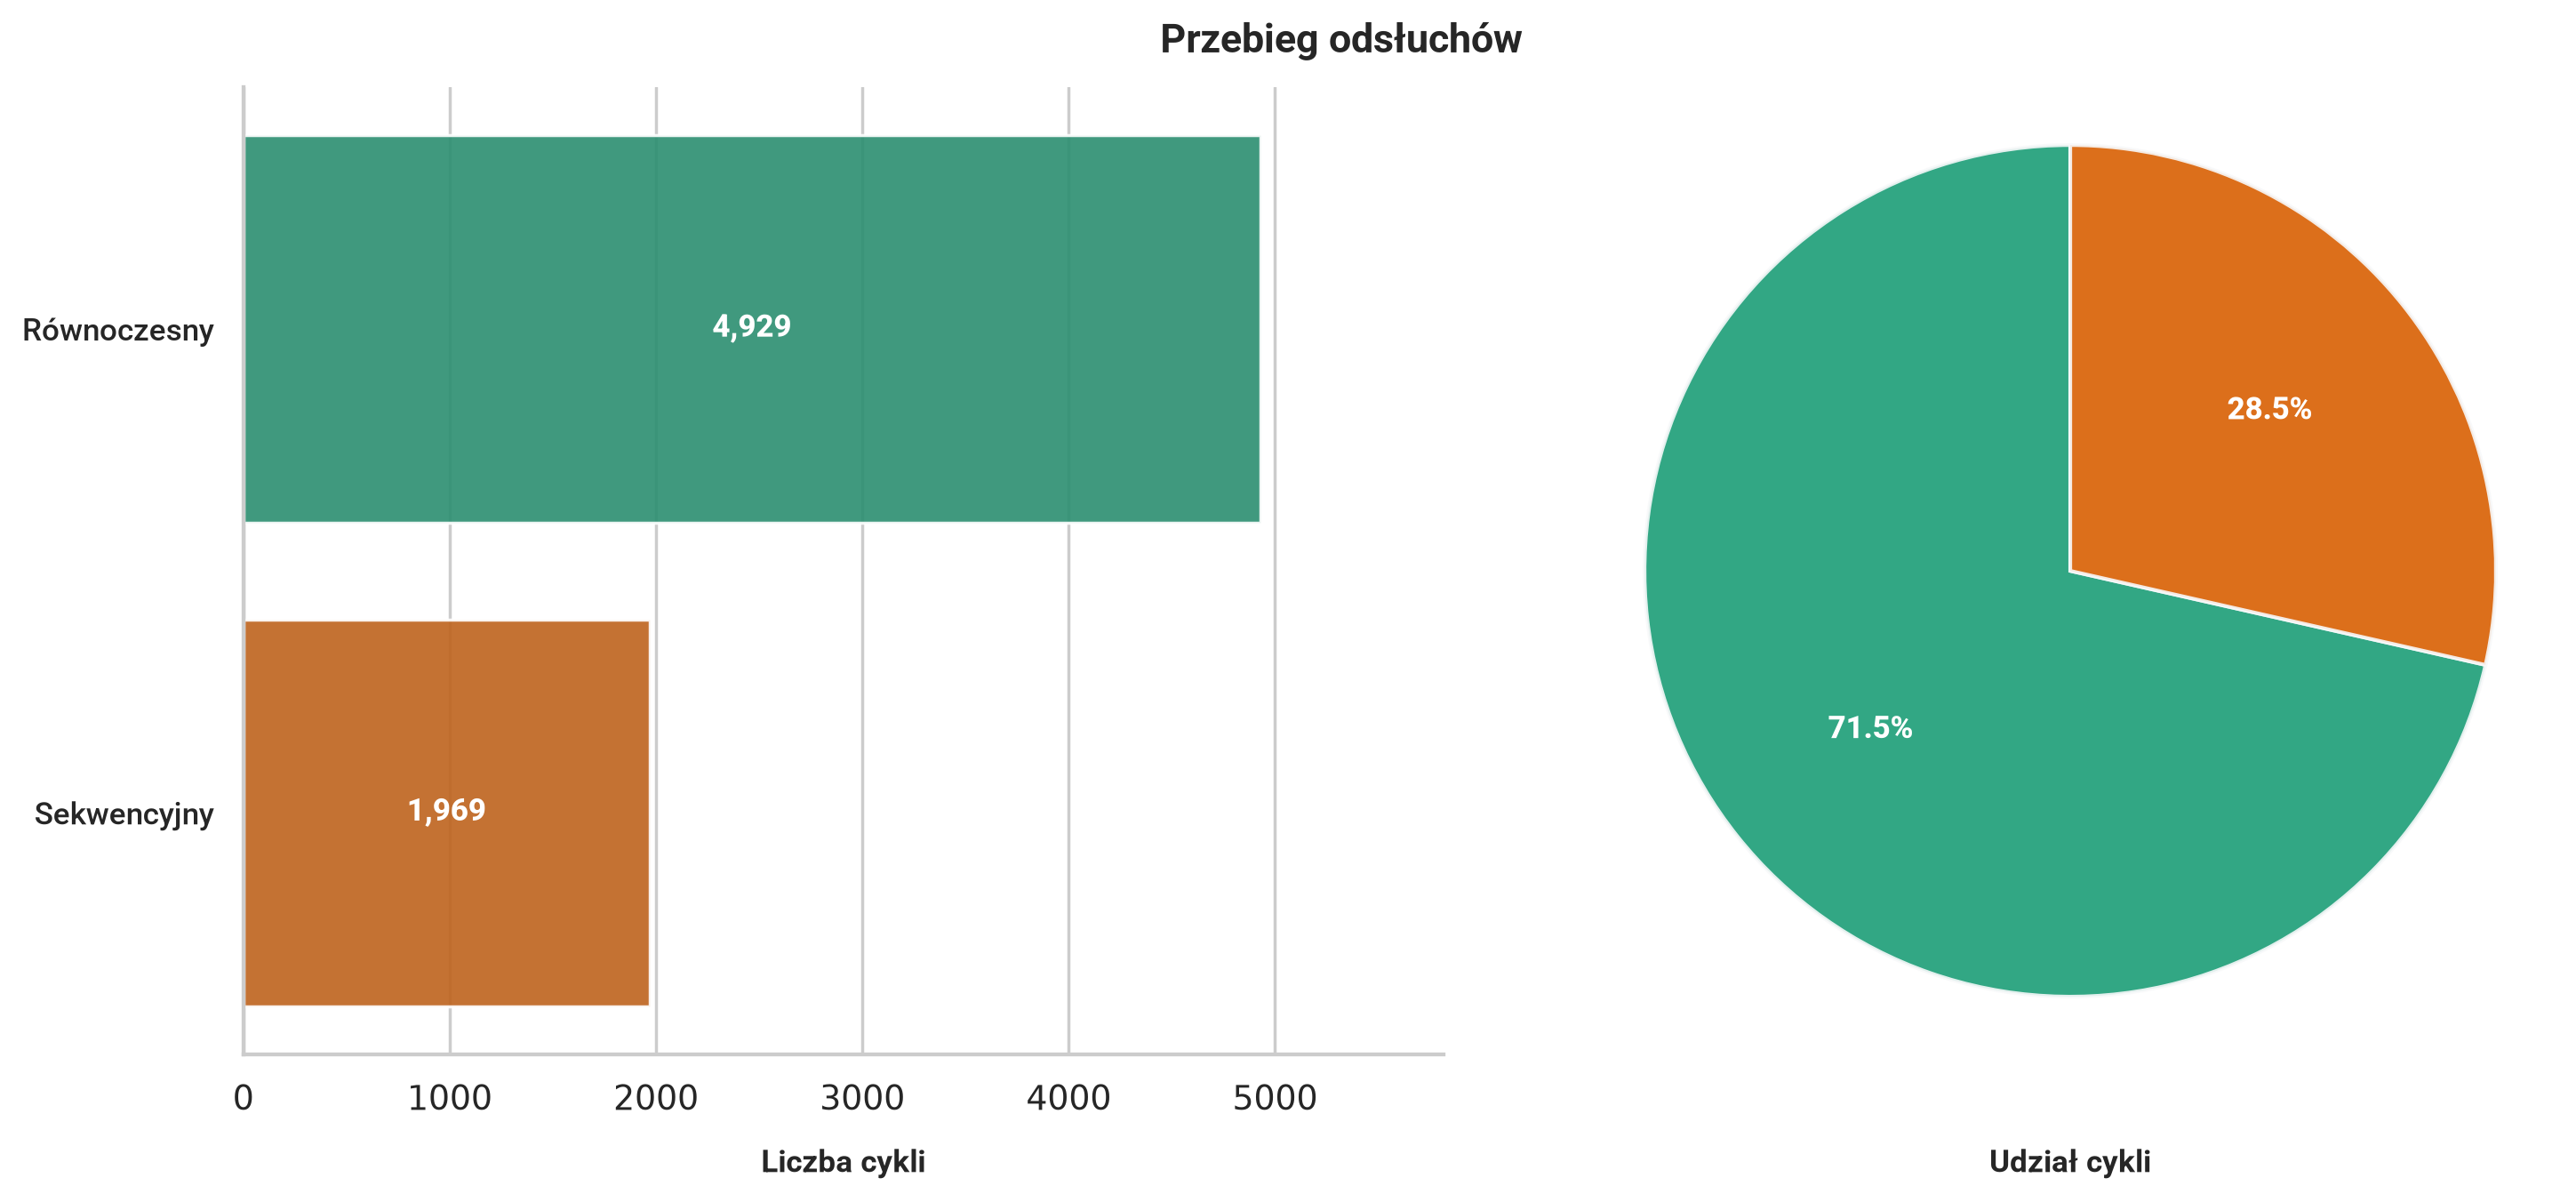

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['acquisition_mode'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:2], strict=True))
labels_map = {
    "mc": "Równoczesny",
    "sc": "Sekwencyjny",
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['acquisition_mode'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Przebieg odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [10]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Przebieg odsłuchów': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Przebieg odsłuchów,Liczebność,Udział (%)
0,Równoczesny,"4,929",71.46%
1,Sekwencyjny,"1,969",28.54%


Nagrania zostały sporządzone w dwóch trybach: sekwencyjnym i równoczesnym. W zależności od trybu, nagrania z różnych miejsc na ciele są zsynchronizowane czasowo lub też rejestrują inne cykle oddechowe. Z powyższych danych wynika, że niemal $3/4$ cykli oddechowych zostało nagranych w trybie równoczesnym, a tylko pozostała $1/4$ w trybie sekwencyjnym. 

Zaobserwowana dysproporcja nie stanowi problemu z punktu widzenia budowy modelu. Głównym celem klasyfikatora będzie detekcja konkretnych patologii akustycznych w obrębie pojedynczych cykli oddechowych, a nie diagnoza pacjenta. W związku z tym, nie ma znaczenia, czy kilka nagrań rejestruje ten sam cykl oddechowy, czy też każdy rejestruje inny. To co ma znaczenie, to czy model w przypadku każdego z tych cykli poprawnie wykryje anomalie oddechowe.

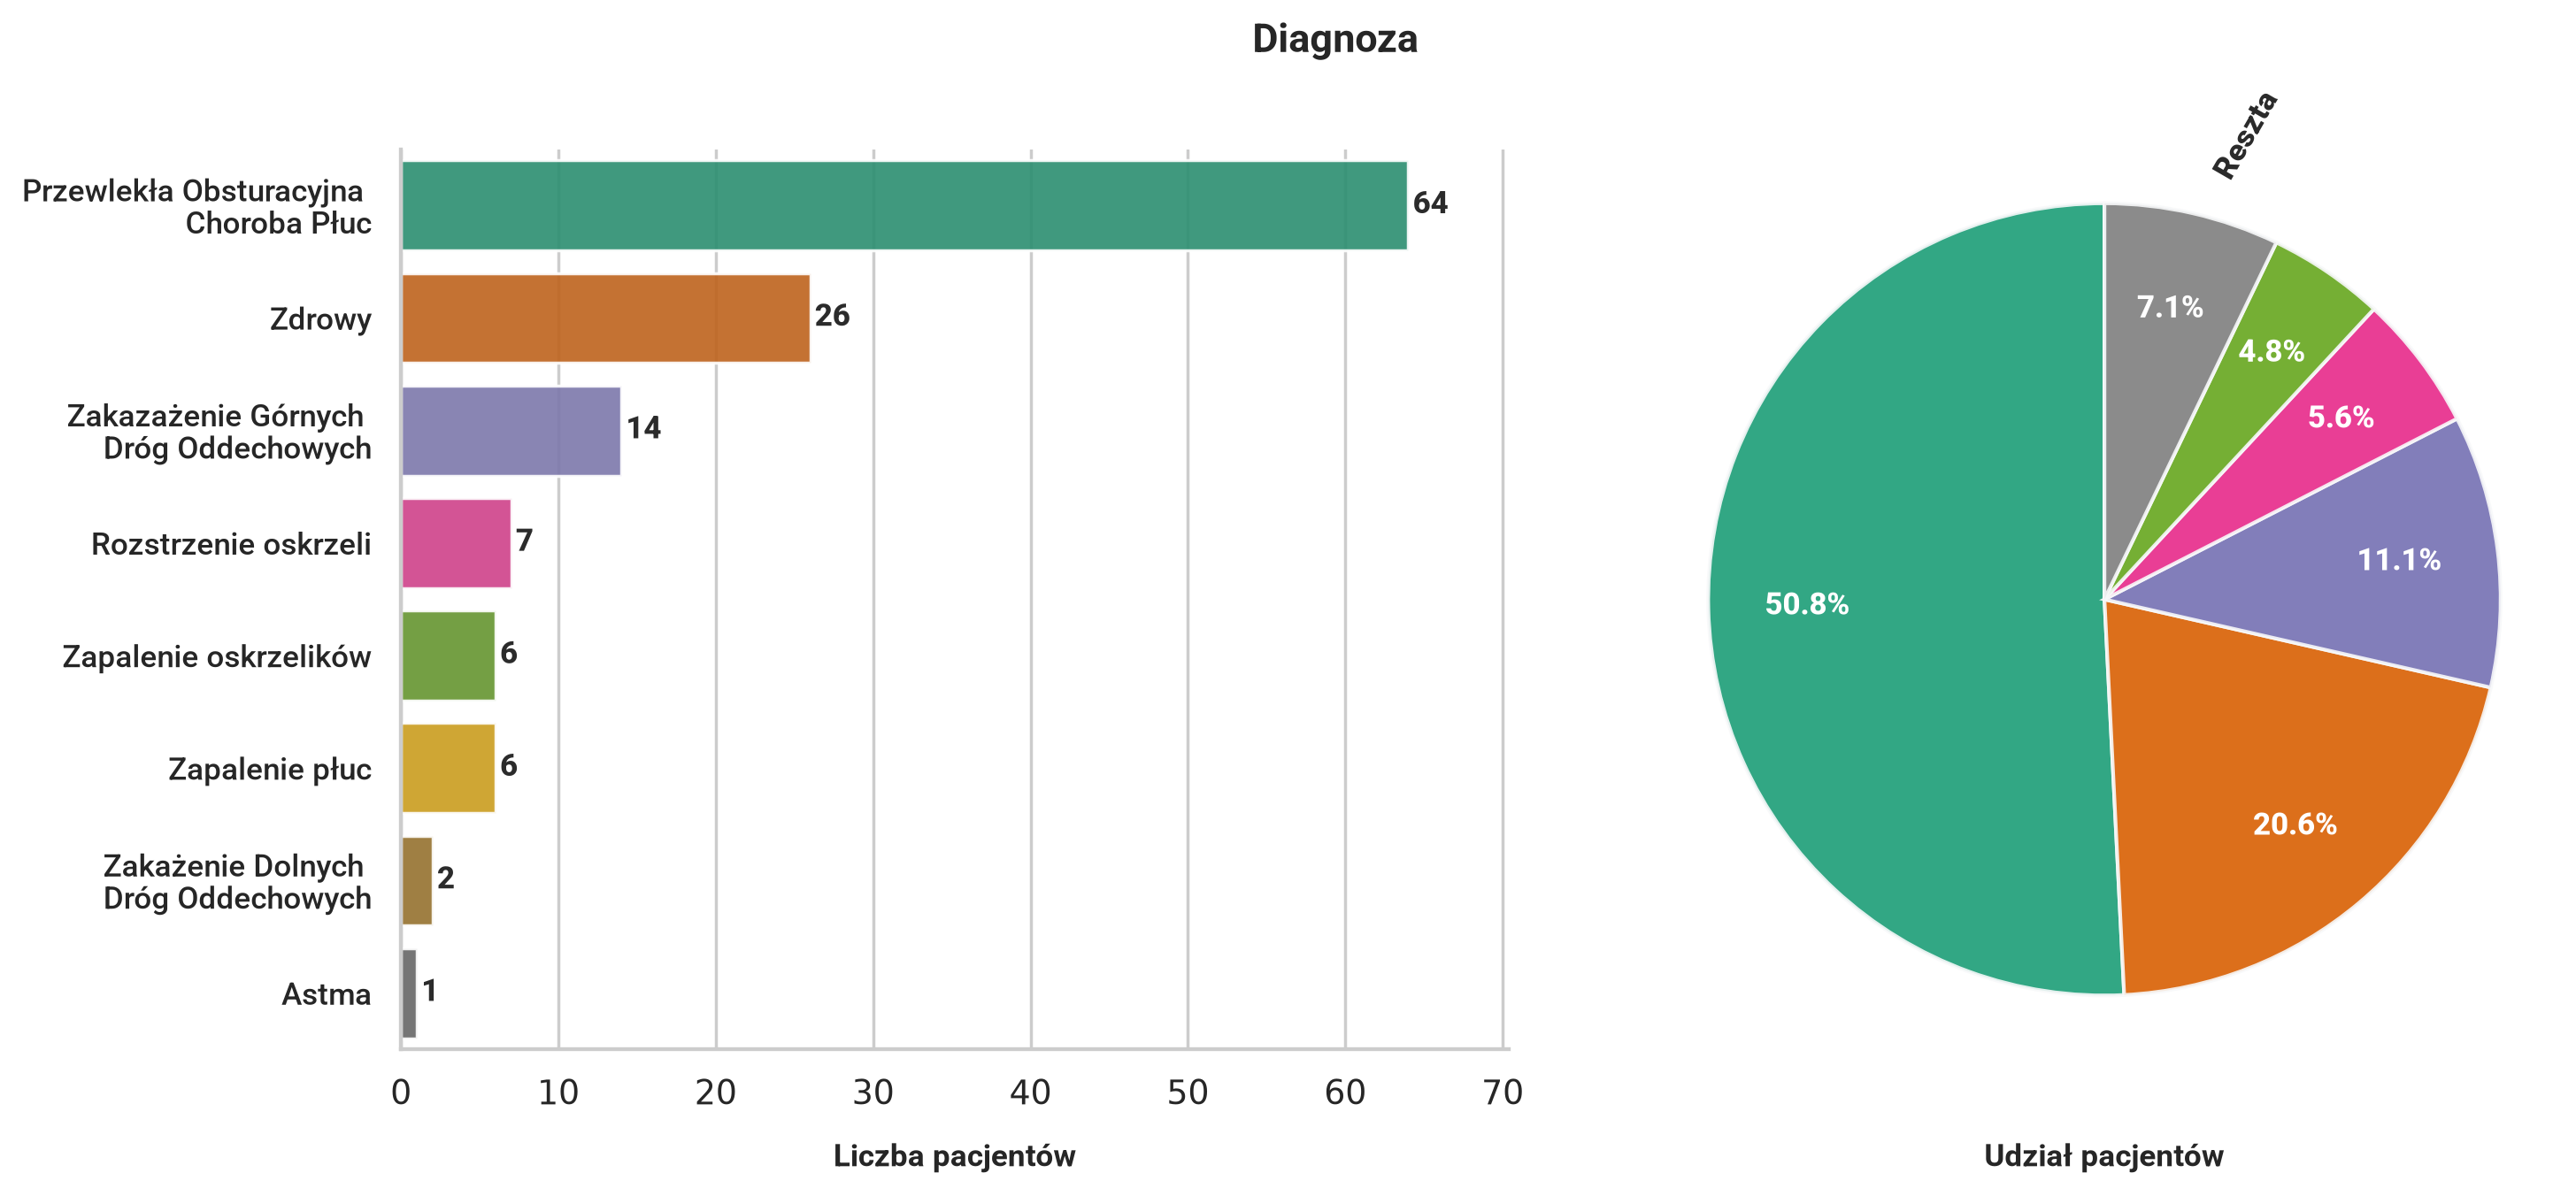

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
df_patients = df[['patient_id','diagnosis']].drop_duplicates().reset_index(drop=True)
counts = df_patients['diagnosis'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:8], strict=True))
labels_map = {
    'COPD': 'Przewlekła Obsturacyjna \nChoroba Płuc',
    'Bronchiectasis': 'Rozstrzenie oskrzeli',
    'Healthy': 'Zdrowy',
    'URTI': 'Zakazażenie Górnych \nDróg Oddechowych',
    'LRTI': 'Zakażenie Dolnych \nDróg Oddechowych',
    'Bronchiolitis': 'Zapalenie oskrzelików',
    'Pneumonia': 'Zapalenie płuc',
    'Asthma': 'Astma'
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="#2b2b2b", label_type="edge", padding=1.5)

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba pacjentów', labelpad=10, font=bold)
ax1.set_xlim(0, df_patients['diagnosis'].value_counts().max() * 1.1)

# Aby zapobiec nagromadzeniu trudnych do odczytania pasków, zgrupujemy małe wartosci w "Reszta"
top_5 = counts.iloc[:5]
others_sum = counts.iloc[5:].sum()
pie_counts = pd.concat([top_5, pd.Series({'Reszta': others_sum})])
pie_color_dict = color_dict.copy()
pie_color_dict['Reszta'] = '#7F7F7F'

# Podpisujemy resztę, aby wykres był zrozumiały
custom_labels = [cat if cat == 'Reszta' else '' for cat in pie_counts.index]

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    pie_counts,
    labels=custom_labels,
    labeldistance=1.2,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    colors=[pie_color_dict[cat] for cat in pie_counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Modyfikacja wyglądu i obrotu etykiety 'Reszta'
for text in texts:
    if text.get_text():
        text.set_rotation(60)
        text.set_font(heavy)
        text.set_fontsize(10)
        text.set_color('#2b2b2b')

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział pacjentów', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Diagnoza ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [12]:
percentages = (counts / len(df_patients)) * 100
pd.DataFrame({'Diagnoza': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Diagnoza,Liczebność,Udział (%)
0,Przewlekła Obsturacyjna \nChoroba Płuc,64,50.79%
1,Zdrowy,26,20.63%
2,Zakazażenie Górnych \nDróg Oddechowych,14,11.11%
3,Rozstrzenie oskrzeli,7,5.56%
4,Zapalenie oskrzelików,6,4.76%
5,Zapalenie płuc,6,4.76%
6,Zakażenie Dolnych \nDróg Oddechowych,2,1.59%
7,Astma,1,0.79%


W przypadku cechy Diagnoza wykresy oraz tabela odnoszą się do liczby pacjentów, a nie do liczby cykli oddechowych. U ponad połowy pacjentów zdiagnozowano Przewlekłą Obturacyjną Chorobę Płuc, natomiast nieco ponad $1/5$ osób zakwalifikowano jako zdrowe. Powyższa cecha jest znacząco niezrównoważona — stosunek liczebności klasy dominującej do najmniej licznej wynosi ponad $64:1$. Podobnie jak w przypadku poprzednich cech, rozkład ten nie stanowi przeszkody metodologicznej, ponieważ głównym celem badawczym jest wykrywanie anomalii w poszczególnych cyklach oddechowych, a nie bezpośrednia diagnoza pacjenta na poziomie globalnym.

## 5. Analiza cech binarnych

---

### 5.1 Trzeszczenia

#TODO